  ### Dans cet exercice, par rapport au notebook précédent, on a ajouté 2 choses:
  
  * Un terme de source ponctuel
  * Le décentrage Upwind est fait correctement, en fonction de la direction de la vitesse
  
  #### Ici on effectue un décentrage 'UPWIND' pour la convection
       
#####  Il est connu que numériquement, un décentrage solutionne le problème de l'instabilité numérique aui arrive si on utilise une approximation centrée de la dérivée d'ordre, pourtant plus précise en théorie, lorsque le nombre de Péclet local dépasse 2.
##### Plusieurs alternatives sont offertes pour solutionner ceci, la plus simple st assurément le décentrage dans le sens du courant: le décentrage Upwind. Celui-ci consiste à utiliser une dérivée numérique décentrée du côté d'ou vient le courant.
                           
##### Ceci est effectué en faisant la dérivée décentrée du côté d'ou vient le courant. On note comme dans le notebook précédentla position des points discrets comme **s, p et n** dans la direction y. **p**  correspond au point central, **n** en **x+dx** et **s** en **x-dx**. Si la vitesse dans la direction y est négative on approxime la dérivée par: $ \frac {dv_y} {dy} = \frac { v_n - v_p} {dy}$ alors que si la vitesse dans la direction y est positive on utilise:$ \frac {dv_y} {dy} = \frac { v_p - v_s} {dy}$. La même méthode s'applique dans les autres directions.


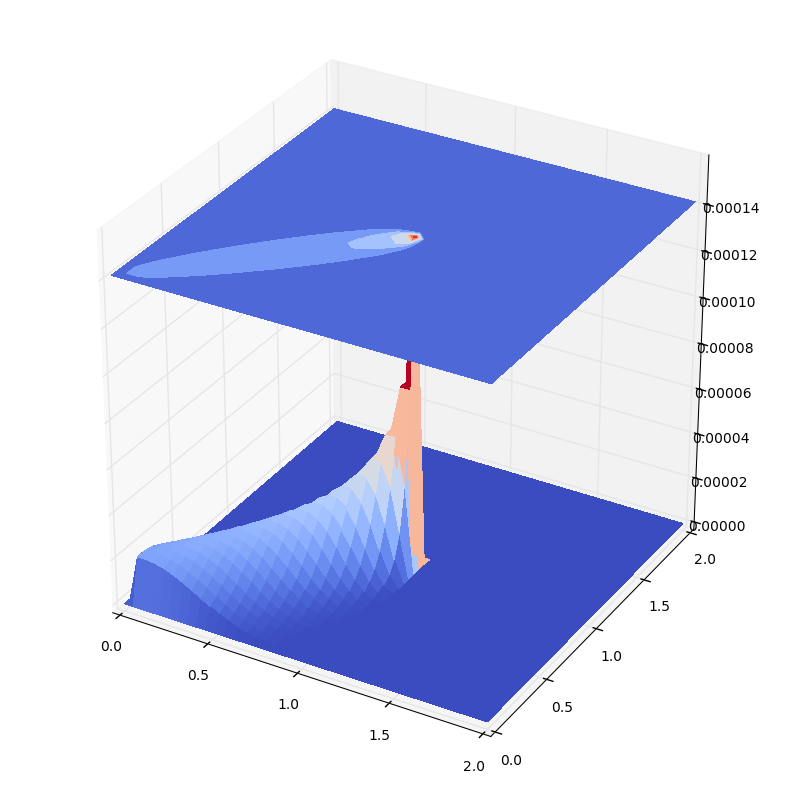

In [12]:
# -*- coding: utf-8 -*-
"""
Created on Mon Dec 19 15:17:02 2016

@author: prop2201
"""
#
# Une fonction pour construire la matrice de D.F.
#
def differencesFinies(NPI,NPJ,aid,ajd,aic,ajc,ap,A,b):
    for i in range( 0 ,NPI):
        for j in range( 0 ,NPJ) :
            p = j*    (NPI)    + i
            pE= j*    (NPI)    + i+1 #  Construction de la matrice de différences finies A x = b
            pO= j*    (NPI)    + i-1 #  de taille (NPI x NPJ)  par (NPI x NPJ)
            pN= (j+1)*(NPI)    + i 
            pS= (j-1)*(NPI)    + i 
            if   i == 0:
                A[p,p] =1.0
                b[p]= 0
            elif i == NII:
                A[p,p]=1.0                      # conditions aux limites
                b[p]=0.0
                A[p,pO]=-1.0                    # Newman à l'EST, gradient nul
            elif j == 0: 
                A[p,p]=1.0
                b[p]=0.0
            elif j == NIJ: 
                A[p,p]=1.0
                b[p]=0.0
            else:

                Uaic=min(aic[i,j],-aic[i,j])            # Upwind
                Uajc=min(ajc[i,j],-ajc[i,j])            # Upwind
                A[p,p]  = ap+Uaic+Uajc                  # matrice, points intérieurs
                A[p,pE] = aid+max(aic[i,j],0)           # Upwind
                A[p,pO] = aid-min(aic[i,j],0)           # ...
                A[p,pN] = ajd+max(ajc[i,j],0)           # ...
                A[p,pS] = ajd-min(ajc[i,j],0)           # ...
    #
    # Source réactive en une région fixée
    #
    im=int(NPI/2)
    jm=int(NPJ/2)
    ip=(1.0/(abs(im)+abs(jm)+0.5))
    pm=jm*    (NPI)    + im
    b[pm]=-ip
    return A,b 
#
#
# Début du code
#
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
from numpy.linalg import solve
%matplotlib inline

NII   = 39         # nombre d'intervalles direction x
NIJ   = 39         # nombre d'intervalles direction y
NPI   = NII+1      # nombre de points direction x
NPJ   = NIJ+1      # nombre de points direction y
ouest = 0.0 
est   = 2
sud   = 0.0
nord  = 2
x     =  np.linspace(ouest , est  ,NPI )
y     =  np.linspace( sud  , nord ,NPJ )
dx    =  x[1]-x[0]
dy    =  y[1]-y[0]
aid   =  .001/dx**2  # coefficient de DF direction x, diffusion
ajd   =  .001/dy**2  # coefficient de DF direction x, diffusion
ap    = -2.0*(aid+ajd)
X,Y   =  np.meshgrid(x,y)
total = (NPI)*(NPJ)
#
#     initialisation du système
#
A     = np.zeros((total,total))
b     = np.zeros(total)
u     = np.zeros((NPI,NPJ))
v     = np.zeros((NPI,NPJ))
aic   = np.zeros((NPI,NPJ))
ajc   = np.zeros((NPI,NPJ))
for i in range(0,NPI):
    for j in range(0,NPJ):
        u[i,j]=-4
        v[i,j]=-4
        aic[i,j]   = -u[i,j]/dx   # coefficient de DF direction x, convection
        ajc[i,j]   = -v[i,j]/dy   # coefficient de DF direction y, convection
#
#     
A,b   = differencesFinies(NPI,NPJ,aid,ajd,aic,ajc,ap,A,b)
c=solve(A, b )                   #   solution directe
C=c.reshape(NPJ,NPI)             #   reconstruire la matrice pour tracer
fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(X, Y, C, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
cset = ax.contourf(X, Y, C, zdir='z', offset=max(c)*0.9, cmap=cm.coolwarm)